**step-1**

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x_train.shape   # size of the training dataset
x_test.shape   # size of the testing dataset

(10000, 28, 28)

**step2**

In [8]:
# since pixel values range from 0-255 divide the pixel values by 255.0 inorder to normalize the pixel values.

x_train = x_train/255.0
x_test = x_test/255.0

In [9]:
# Reshaping the size of images
x_train = x_train.reshape(-1, 28, 28 ,1)  # here before there was no channel info. for cnn channel information . since images are gray scale the channel is 1.
x_test = x_test.reshape(-1,28, 28 ,1)

In [10]:
# one hpt encoding is done to convert raw numbers to binary vector so that cnn's can easily learn.
y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test,10)

**step3**

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')

]) # Sequential convolutional neural network with input layers pooling and dropout layers(to prevent overfitting)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

**step4  training the model**

In [13]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.8857 - loss: 0.3604 - val_accuracy: 0.9746 - val_loss: 0.0894
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.9668 - loss: 0.1118 - val_accuracy: 0.9843 - val_loss: 0.0523
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 99ms/step - accuracy: 0.9755 - loss: 0.0814 - val_accuracy: 0.9876 - val_loss: 0.0461
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.9790 - loss: 0.0685 - val_accuracy: 0.9872 - val_loss: 0.0446
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.9825 - loss: 0.0566 - val_accuracy: 0.9880 - val_loss: 0.0409
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9838 - loss: 0.0521 - val_accuracy: 0.9901 - val_loss: 0.0353
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.9856 - loss: 0.0459 - val_accuracy: 0.9896 - val_loss: 0.0364
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - accuracy: 0.9864 - loss: 0.04

step5 testing the model

In [14]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9923 - loss: 0.0238
Test Accuracy : 0.9922999739646912


**step6  testing the model with custom images**

**step6 testing the model with custom images**

In [25]:
from tensorflow.keras.preprocessing import image

img = image.load_img('digit8.png', target_size=(28,28), color_mode='grayscale')
img = image.img_to_array(img) # actual image is 6
img = img/255.0
img = img.reshape(1,28,28,1)

prediction = model.predict(img)
predicted_digit =np.argmax(prediction)
print("Predicted Digit :", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Digit : 6


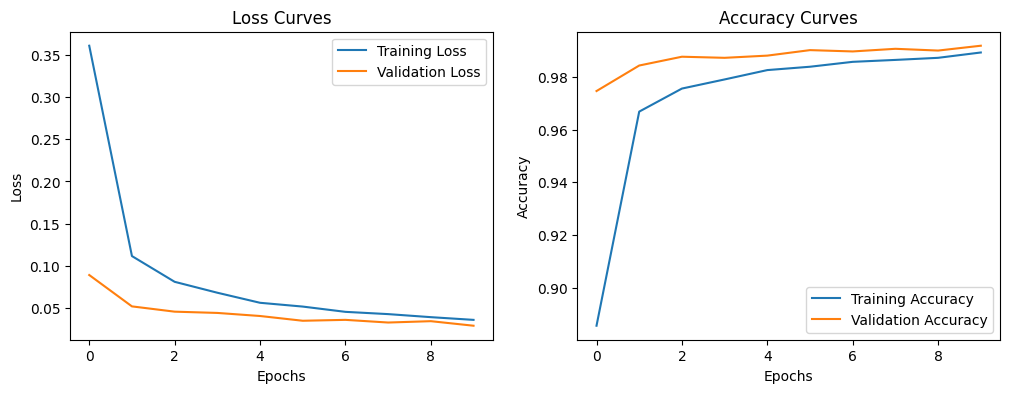

In [26]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
#